<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/Xayne's-RF-(Random-Forest)/Xayne's_Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Random Forest**

Data Loading & Cleaning

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA
# ==========================================
# Load the file
df = pd.read_csv('synthetic_data_cleaned_feature_engineered.csv', sep='|', on_bad_lines='skip', engine='python')

# --- FIX: CLEAN COLUMN NAMES ---
# The file has "Log_Income,," as a header. This fixes it.
df.columns = df.columns.str.replace(',,', '').str.strip()

# Cleanup: Remove accidental empty columns (trailing commas)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop rows where Target is missing
df = df.dropna(subset=['Default_Status'])
df['Default_Status'] = df['Default_Status'].astype(int)

Feature Selection

In [15]:
# ==========================================
# 2. SELECT FEATURES
# ==========================================
features = [
    'Age',
    'Annual_Income',
    'Credit_Score',
    'Loan_Amount',
    'Loan_Term_Months',
    'DTI_Ratio',
    'Log_Income',
    'Risk_Flag',
    'Occupation',
    'Has_Asset'
]

# Create X (Features) and y (Target)
X = df[features].copy()
y = df['Default_Status']

Preprocessing

In [10]:
# ==========================================
# 3. PREPROCESSING
# ==========================================
# Identify truly numeric columns that are not handled separately
numeric_cols_for_conversion = [col for col in features if col not in ['Occupation', 'Has_Asset']]

# Convert these columns to numeric, coercing errors to NaN
for col in numeric_cols_for_conversion:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Encode Occupation (Text -> Numbers)
X = pd.get_dummies(X, columns=['Occupation'], drop_first=True)

# Encode Asset (Yes/No -> 1/0)
if 'Has_Asset' in X.columns:
    X['Has_Asset'] = pd.to_numeric(X['Has_Asset'].replace({'Yes': 1, 'No': 0}), errors='coerce').fillna(0)

# Fill any remaining missing values (from coerce or original NaNs) with 0
X = X.fillna(0)

Model Training

In [11]:
from sklearn.model_selection import GridSearchCV

# ==========================================
# 4. OPTIMIZED MODEL TRAINING (Hyperparameter Tuning)
# ==========================================
print("⏳ Starting Grid Search to find best parameters...")

# 1. Define the "Grid" of settings to test
param_grid = {
    'n_estimators': [100, 200],        # Try 100 and 200 trees
    'max_depth': [None, 10, 20],       # Try limiting depth to prevent overfitting
    'min_samples_split': [2, 5, 10],   # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]      # Minimum samples at a leaf
}

# 2. Setup the Grid Search
# cv=3 means it splits data into 3 parts to cross-validate (very robust)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,  # Use all CPU cores
    scoring='accuracy',
    verbose=1
)

# 3. Train on all combinations
grid_search.fit(X_train, y_train)

# 4. Get the Winner
best_rf_model = grid_search.best_estimator_

print(f"✅ Best Parameters Found: {grid_search.best_params_}")
print(f"✅ Best Training Accuracy (CV): {grid_search.best_score_:.2%}")

# IMPORTANT: From now on, use 'best_rf_model' instead of 'rf_model'

⏳ Starting Grid Search to find best parameters...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
✅ Best Parameters Found: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
✅ Best Training Accuracy (CV): 90.60%


Evaluation

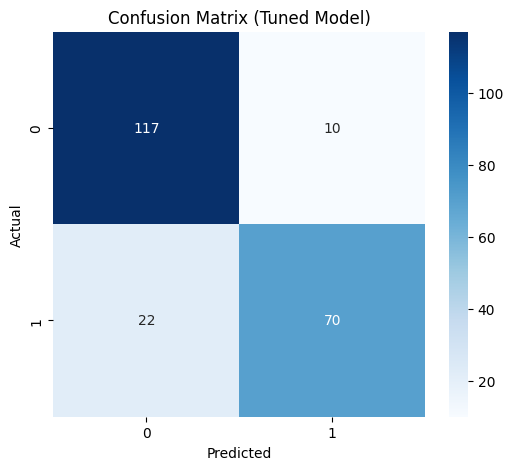


📊 FINAL MODEL EVALUATION (Tuned Random Forest)
---------------------------------------
1. Accuracy:  85.39%  (Overall correctness)
2. F1-Score:  0.8140  (Balance of Precision/Recall)
3. Recall:    76.09%  (How many defaulters we caught)
4. ROC-AUC:   0.8607  (Discrimination ability)
---------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       127
           1       0.88      0.76      0.81        92

    accuracy                           0.85       219
   macro avg       0.86      0.84      0.85       219
weighted avg       0.86      0.85      0.85       219



In [13]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 5. EVALUATE THE TUNED MODEL
# ==========================================
# Use the optimized model (best_rf_model) for predictions
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]  # Probability needed for ROC-AUC

# --- A. VISUALIZATIONS ---
# 1. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Tuned Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- B. THE "BIG 4" METRICS TABLE ---
# Calculate metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n📊 FINAL MODEL EVALUATION (Tuned Random Forest)")
print(f"---------------------------------------")
print(f"1. Accuracy:  {acc:.2%}  (Overall correctness)")
print(f"2. F1-Score:  {f1:.4f}  (Balance of Precision/Recall)")
print(f"3. Recall:    {recall:.2%}  (How many defaulters we caught)")
print(f"4. ROC-AUC:   {auc:.4f}  (Discrimination ability)")
print(f"---------------------------------------")

# --- C. DETAILED REPORT ---
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Feature Importance

In [14]:
# Feature Importance
print("\n🏆 Top Predictors (Tuned):")
# We access feature_importances_ from the best estimator
print(pd.Series(best_rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5))


🏆 Top Predictors (Tuned):
DTI_Ratio        0.390437
Risk_Flag        0.289130
Loan_Amount      0.097824
Annual_Income    0.054992
Credit_Score     0.048020
dtype: float64
